In [1]:
### Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [34]:
# Setting output path

from pathlib import Path

FIGURES_DIR = Path("../outputs/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
### Load processed data

file_path = "../data/processed/london_air_quality_weather_2021_2024.csv"

df = pd.read_csv(file_path)

df["Datetime"] = pd.to_datetime(df["Datetime"])

print("Shape:", df.shape)
df.head()

Shape: (168015, 13)


,Datetime,Station,NO2,PM10,PM2.5,O3,Temperature,Dewpoint,Humidity,WindSpeed,WindDirection,Pressure,Visibility
0,2021-01-01 01:00:00,London Bloomsbury,28.35369,18.358,20.0,29.53636,0.2,-0.7,91.8,2.0,340.0,1009.6,350.0
1,2021-01-01 02:00:00,London Bloomsbury,25.03474,22.223,19.0,34.92475,0.2,-0.6,93.9,2.0,320.0,1009.9,400.0
2,2021-01-01 03:00:00,London Bloomsbury,22.63855,22.223,14.0,38.86626,0.0,-0.6,95.7,4.0,280.0,1010.3,320.0
3,2021-01-01 04:00:00,London Bloomsbury,52.45771,17.392,17.0,22.55141,-0.2,-0.7,95.7,4.0,290.0,1010.3,250.0
4,2021-01-01 05:00:00,London Bloomsbury,75.17713,24.155,20.0,10.07828,-0.7,-1.0,97.2,6.0,270.0,1010.2,50.0


In [3]:
### Inspect dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168015 entries, 0 to 168014
Data columns (total 13 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Datetime       168015 non-null  datetime64[ns]
 1   Station        168015 non-null  object        
 2   NO2            130270 non-null  float64       
 3   PM10           162245 non-null  float64       
 4   PM2.5          154357 non-null  float64       
 5   O3             132744 non-null  float64       
 6   Temperature    167975 non-null  float64       
 7   Dewpoint       167975 non-null  float64       
 8   Humidity       167960 non-null  float64       
 9   WindSpeed      165205 non-null  float64       
 10  WindDirection  165205 non-null  float64       
 11  Pressure       167965 non-null  float64       
 12  Visibility     167085 non-null  float64       
dtypes: datetime64[ns](1), float64(11), object(1)
memory usage: 16.7+ MB


In [4]:
### Check date range

print("Start:", df["Datetime"].min())
print("End:", df["Datetime"].max())

Start: 2021-01-01 01:00:00
End: 2024-12-31 23:00:00


In [5]:
### Check monitoring stations

station_counts = df["Station"].value_counts()

print(station_counts)

Station
London Bloomsbury         33603
London Harlington         33603
London Honor Oak Park     33603
London Marylebone Road    33603
London N. Kensington      33603
Name: count, dtype: int64


In [6]:
### Check missing values

missing_pct = (
    df.isna()
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

print(missing_pct)

NO2              22.47
O3               20.99
PM2.5             8.13
PM10              3.43
WindSpeed         1.67
WindDirection     1.67
Visibility        0.55
Humidity          0.03
Pressure          0.03
Temperature       0.02
Dewpoint          0.02
Datetime          0.00
Station           0.00
dtype: float64


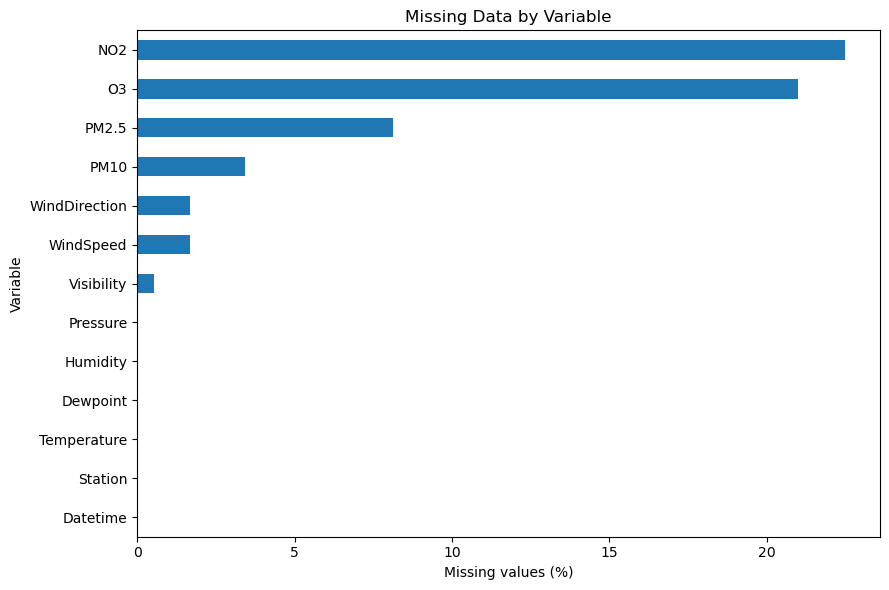

In [7]:
### Visualize missing values

missing_pct.sort_values().plot(
    kind="barh",
    figsize=(9, 6)
)

plt.xlabel("Missing values (%)")
plt.ylabel("Variable")
plt.title("Missing Data by Variable")
plt.tight_layout()
plt.show()

In [8]:
### Summarize PM2.5

df["PM2.5"].describe()

count    154357.000000
mean          8.355164
std           6.880184
min          -4.000000
25%           4.115000
50%           6.368000
75%          10.189000
max         121.321000
Name: PM2.5, dtype: float64

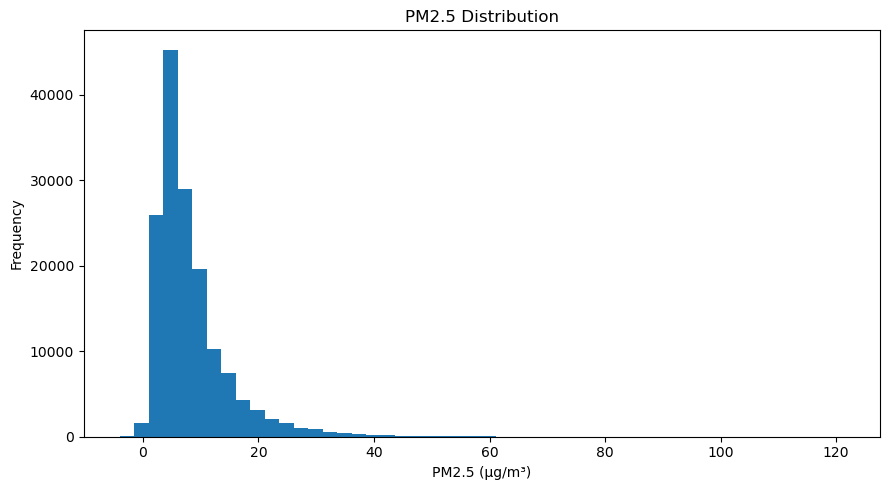

In [37]:
# Plotting PM2.5 distribution

plt.figure(figsize=(9, 5))

df["PM2.5"].dropna().plot(
    kind="hist",
    bins=50
)

plt.xlabel("PM2.5 (µg/m³)")
plt.ylabel("Frequency")
plt.title("PM2.5 Distribution")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "pm25_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

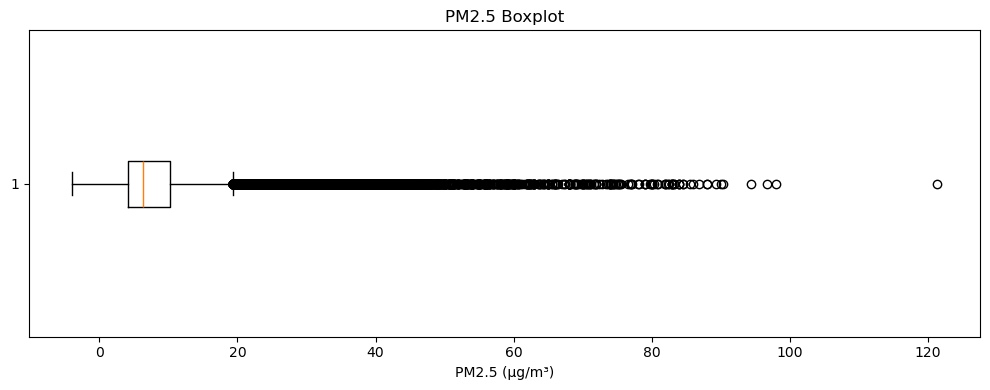

In [10]:
### Detect PM2.5 outliers

plt.figure(figsize=(10, 4))

plt.boxplot(
    df["PM2.5"].dropna(),
    vert=False
)

plt.xlabel("PM2.5 (µg/m³)")
plt.title("PM2.5 Boxplot")

plt.tight_layout()
plt.show()

In [11]:
### Compare PM2.5 by station

station_pm25 = (
    df.groupby("Station")["PM2.5"]
    .mean()
    .sort_values(ascending=False)
)

print(station_pm25)

Station
London Marylebone Road    10.961814
London N. Kensington       8.046754
London Bloomsbury          8.007626
London Honor Oak Park      7.611900
London Harlington          7.298359
Name: PM2.5, dtype: float64


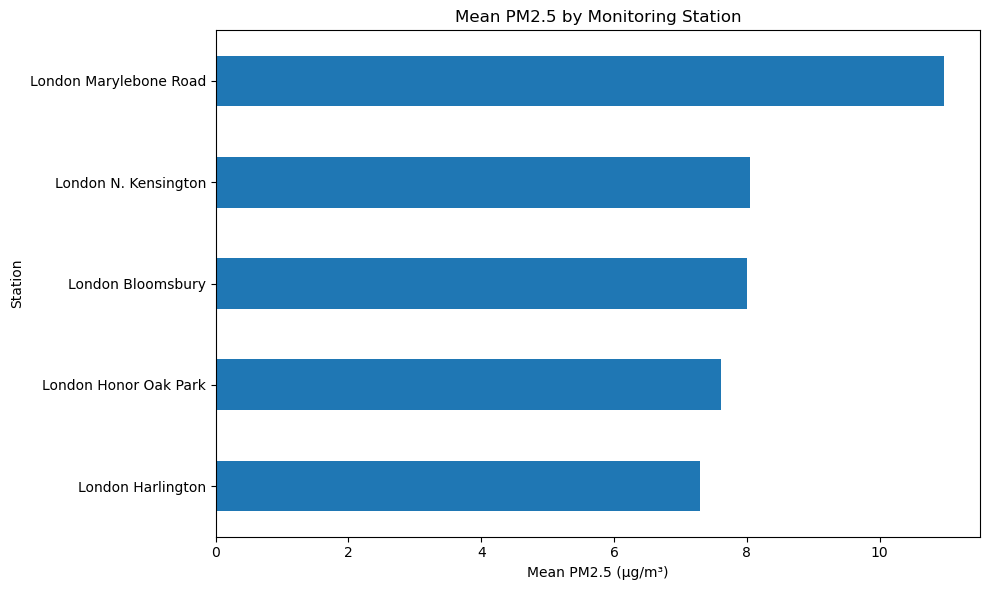

In [38]:
# Calculating station averages

station_pm25 = (
    df.groupby("Station")["PM2.5"]
    .mean()
    .sort_values(ascending=False)
)

station_pm25.round(2)

# Plotting PM2.5 by station

plt.figure(figsize=(10, 6))

station_pm25.sort_values().plot(
    kind="barh"
)

plt.xlabel("Mean PM2.5 (µg/m³)")
plt.ylabel("Station")
plt.title("Mean PM2.5 by Monitoring Station")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "pm25_by_station.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [13]:
### Summarize pollutants by station

station_summary = (
    df.groupby("Station")[["NO2", "PM10", "PM2.5", "O3"]]
    .mean()
    .round(2)
)

station_summary

,NO2,PM10,PM2.5,O3
Station,,,,
London Bloomsbury,24.75,14.77,8.01,47.96
London Harlington,21.23,12.30,7.30,46.56
London Honor Oak Park,NaN,12.12,7.61,47.67
London Marylebone Road,41.54,18.70,10.96,29.30
London N. Kensington,17.87,13.14,8.05,52.79


In [14]:
### Create time features

df["Year"] = df["Datetime"].dt.year
df["Month"] = df["Datetime"].dt.month
df["MonthName"] = df["Datetime"].dt.month_name()
df["Hour"] = df["Datetime"].dt.hour
df["DayOfWeek"] = df["Datetime"].dt.dayofweek

df.head()

,Datetime,Station,NO2,PM10,PM2.5,O3,Temperature,Dewpoint,Humidity,WindSpeed,WindDirection,Pressure,Visibility,Year,Month,MonthName,Hour,DayOfWeek
0,2021-01-01 01:00:00,London Bloomsbury,28.35369,18.358,20.0,29.53636,0.2,-0.7,91.8,2.0,340.0,1009.6,350.0,2021,1,January,1,4
1,2021-01-01 02:00:00,London Bloomsbury,25.03474,22.223,19.0,34.92475,0.2,-0.6,93.9,2.0,320.0,1009.9,400.0,2021,1,January,2,4
2,2021-01-01 03:00:00,London Bloomsbury,22.63855,22.223,14.0,38.86626,0.0,-0.6,95.7,4.0,280.0,1010.3,320.0,2021,1,January,3,4
3,2021-01-01 04:00:00,London Bloomsbury,52.45771,17.392,17.0,22.55141,-0.2,-0.7,95.7,4.0,290.0,1010.3,250.0,2021,1,January,4,4
4,2021-01-01 05:00:00,London Bloomsbury,75.17713,24.155,20.0,10.07828,-0.7,-1.0,97.2,6.0,270.0,1010.2,50.0,2021,1,January,5,4


In [15]:
### Analyze monthly PM2.5

monthly_pm25 = (
    df.groupby("Month")["PM2.5"]
    .mean()
)

print(monthly_pm25)

Month
1      9.661389
2      8.795193
3     11.570349
4      8.612041
5      7.991252
6      7.753147
7      6.264456
8      6.472357
9      8.780076
10     7.243266
11     9.114317
12     8.168434
Name: PM2.5, dtype: float64


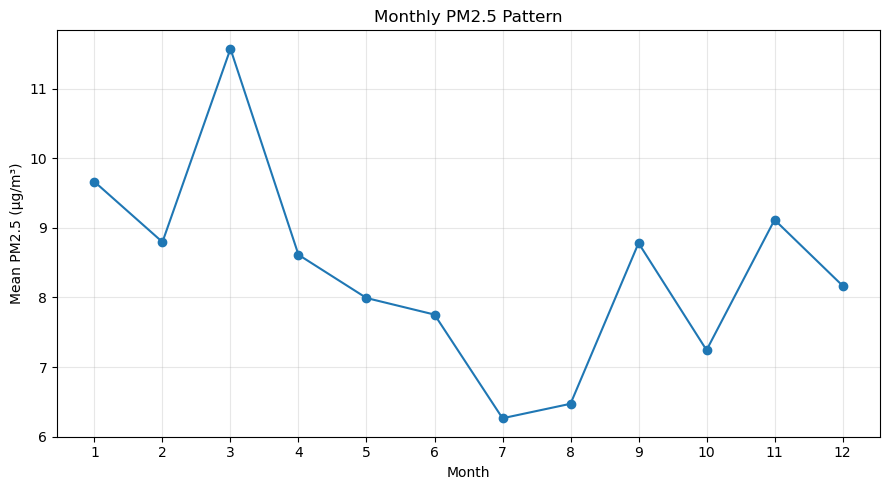

In [40]:
# Calculating monthly PM2.5

monthly_pm25 = (
    df.groupby("Month")["PM2.5"]
    .mean()
)

monthly_pm25.round(2)


# Plotting monthly PM2.5

plt.figure(figsize=(9, 5))

monthly_pm25.plot(
    kind="line",
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Mean PM2.5 (µg/m³)")
plt.title("Monthly PM2.5 Pattern")

plt.xticks(range(1, 13))
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "pm25_monthly_pattern.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

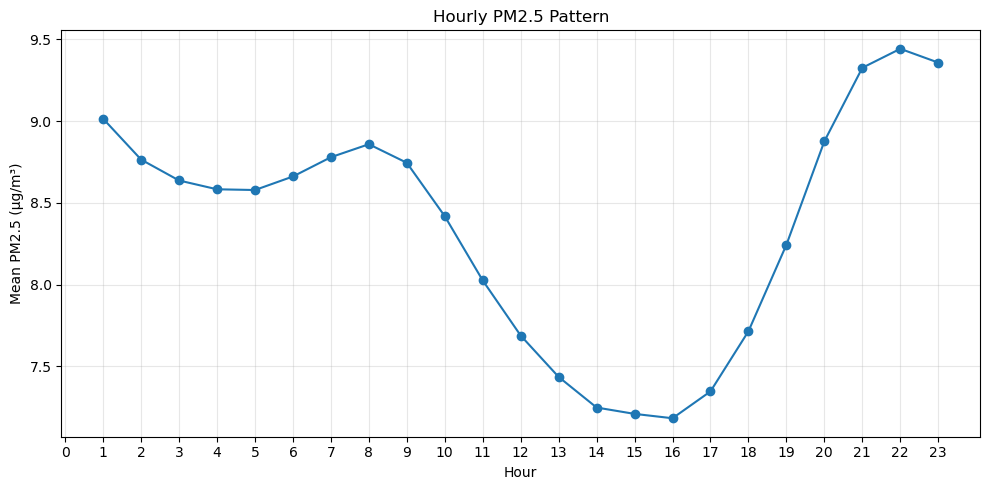

In [41]:
# Calculating hourly PM2.5

hourly_pm25 = (
    df.groupby("Hour")["PM2.5"]
    .mean()
)

hourly_pm25.round(2)



# Plotting hourly PM2.5

plt.figure(figsize=(10, 5))

hourly_pm25.plot(
    kind="line",
    marker="o"
)

plt.xlabel("Hour")
plt.ylabel("Mean PM2.5 (µg/m³)")
plt.title("Hourly PM2.5 Pattern")

plt.xticks(range(0, 24))
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "pm25_hourly_pattern.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Year
2021    8.997981
2022    8.696036
2023    8.231716
2024    7.621672
Name: PM2.5, dtype: float64


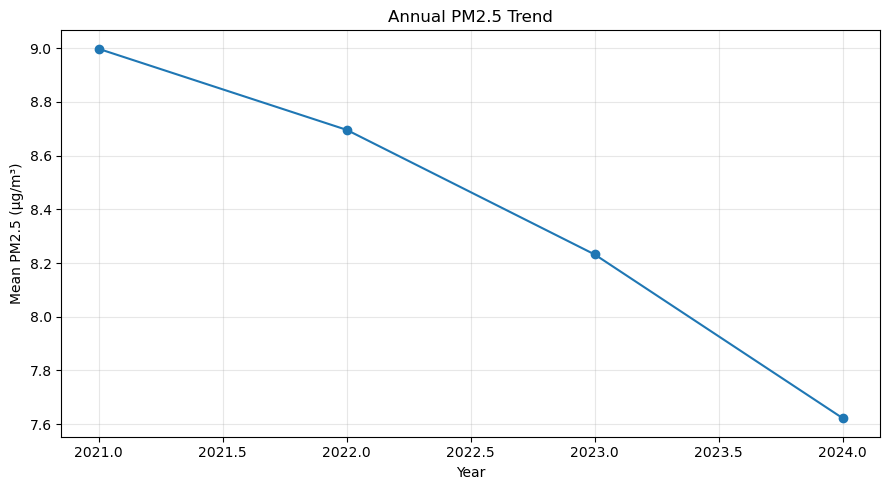

In [39]:
### Analyze annual PM2.5

annual_pm25 = (
    df.groupby("Year")["PM2.5"]
    .mean()
)

print(annual_pm25)

# Plotting annual PM2.5

plt.figure(figsize=(9, 5))

annual_pm25.plot(
    kind="line",
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Mean PM2.5 (µg/m³)")
plt.title("Annual PM2.5 Trend")

plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "pm25_annual_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

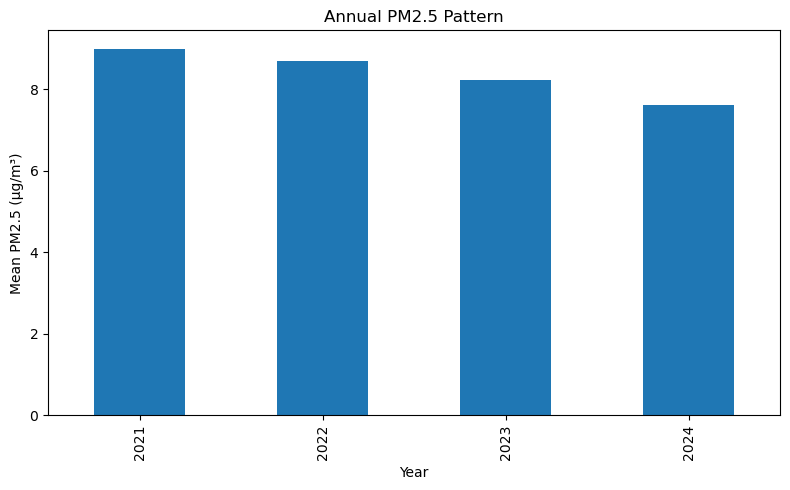

In [20]:
### Plot annual PM2.5

plt.figure(figsize=(8, 5))

annual_pm25.plot(
    kind="bar"
)

plt.xlabel("Year")
plt.ylabel("Mean PM2.5 (µg/m³)")
plt.title("Annual PM2.5 Pattern")

plt.tight_layout()
plt.show()

In [21]:
### Calculate pollutant correlations

pollutants = [
    "NO2",
    "PM10",
    "PM2.5",
    "O3"
]

correlation = df[pollutants].corr()

correlation.round(2)

,NO2,PM10,PM2.5,O3
NO2,1.00,0.45,0.45,-0.65
PM10,0.45,1.00,0.83,-0.21
PM2.5,0.45,0.83,1.00,-0.31
O3,-0.65,-0.21,-0.31,1.00


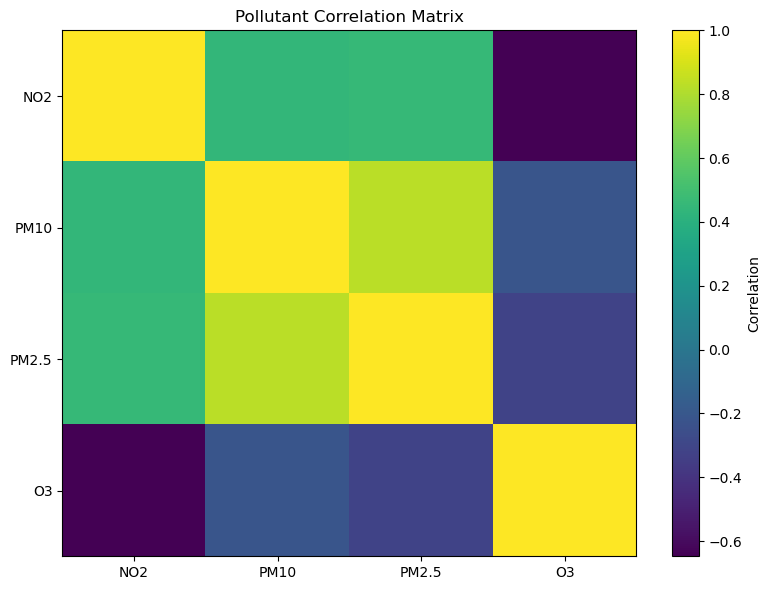

In [22]:
### Plot pollutant correlations

plt.figure(figsize=(8, 6))

plt.imshow(
    correlation,
    aspect="auto"
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(pollutants)),
    pollutants
)

plt.yticks(
    range(len(pollutants)),
    pollutants
)

plt.title("Pollutant Correlation Matrix")

plt.tight_layout()
plt.show()

In [23]:
### Correlate weather with PM2.5

weather_variables = [
    "Temperature",
    "Dewpoint",
    "Humidity",
    "WindSpeed",
    "WindDirection",
    "Pressure",
    "Visibility"
]

weather_corr = (
    df[weather_variables + ["PM2.5"]]
    .corr()["PM2.5"]
    .drop("PM2.5")
    .sort_values()
)

print(weather_corr.round(3))

Visibility      -0.476
WindSpeed       -0.294
WindDirection   -0.184
Temperature     -0.160
Dewpoint        -0.126
Humidity         0.100
Pressure         0.211
Name: PM2.5, dtype: float64


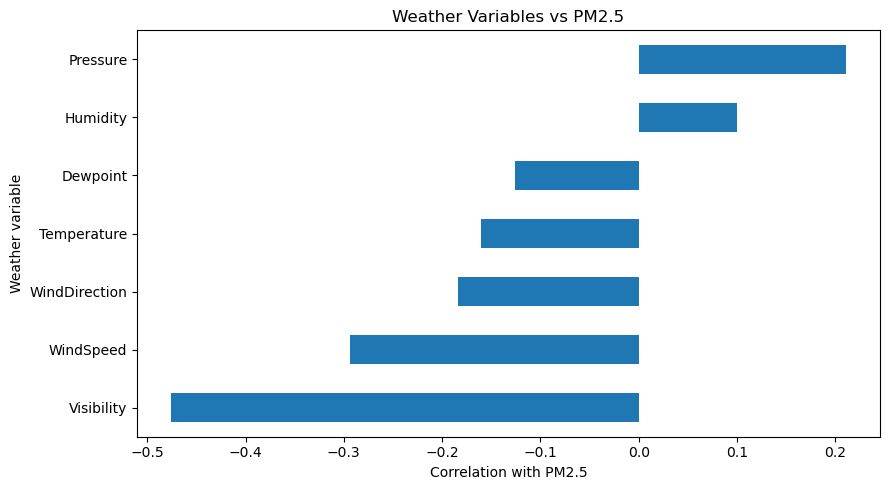

In [24]:
### Plot weather correlations

plt.figure(figsize=(9, 5))

weather_corr.plot(
    kind="barh"
)

plt.xlabel("Correlation with PM2.5")
plt.ylabel("Weather variable")
plt.title("Weather Variables vs PM2.5")

plt.tight_layout()
plt.show()

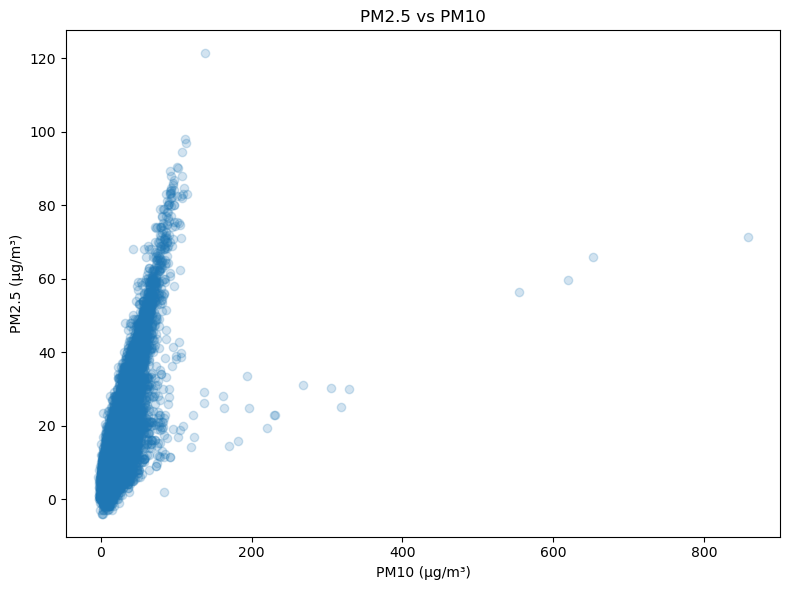

In [25]:
### Compare PM2.5 and PM10

sample = df[
    ["PM2.5", "PM10"]
].dropna()

plt.figure(figsize=(8, 6))

plt.scatter(
    sample["PM10"],
    sample["PM2.5"],
    alpha=0.2
)

plt.xlabel("PM10 (µg/m³)")
plt.ylabel("PM2.5 (µg/m³)")
plt.title("PM2.5 vs PM10")

plt.tight_layout()
plt.show()

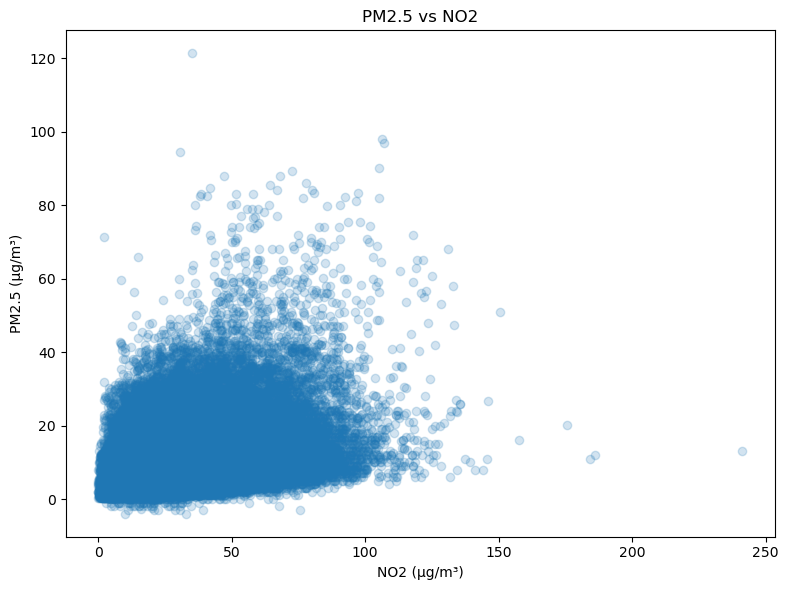

In [26]:
### Compare PM2.5 and NO2

sample = df[
    ["PM2.5", "NO2"]
].dropna()

plt.figure(figsize=(8, 6))

plt.scatter(
    sample["NO2"],
    sample["PM2.5"],
    alpha=0.2
)

plt.xlabel("NO2 (µg/m³)")
plt.ylabel("PM2.5 (µg/m³)")
plt.title("PM2.5 vs NO2")

plt.tight_layout()
plt.show()

In [27]:
### Check PM2.5 availability

pm25_availability = (
    df.groupby("Station")["PM2.5"]
    .agg(
        Total="size",
        Available="count"
    )
)

pm25_availability["Availability_%"] = (
    pm25_availability["Available"] /
    pm25_availability["Total"] *
    100
).round(2)

pm25_availability = pm25_availability.sort_values(
    "Availability_%",
    ascending=False
)

pm25_availability

,Total,Available,Availability_%
Station,,,
London Harlington,33603,33446,99.53
London N. Kensington,33603,33398,99.39
London Honor Oak Park,33603,33186,98.76
London Marylebone Road,33603,30192,89.85
London Bloomsbury,33603,24135,71.82


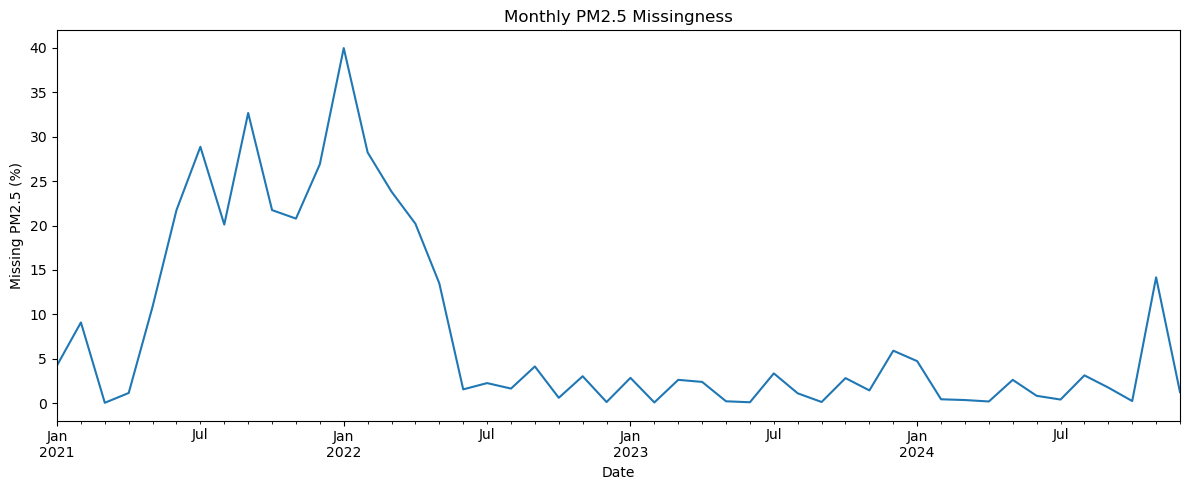

In [28]:
### Analyze PM2.5 missingness over time

monthly_missing_pm25 = (
    df.set_index("Datetime")["PM2.5"]
    .resample("ME")
    .apply(lambda x: x.isna().mean() * 100)
)

plt.figure(figsize=(12, 5))

monthly_missing_pm25.plot()

plt.xlabel("Date")
plt.ylabel("Missing PM2.5 (%)")
plt.title("Monthly PM2.5 Missingness")

plt.tight_layout()
plt.show()

In [29]:
### Summarize EDA

print("=" * 60)
print("EDA SUMMARY")
print("=" * 60)

print("\nDataset shape:")
print(df.shape)

print("\nDate range:")
print(df["Datetime"].min(), "→", df["Datetime"].max())

print("\nStations:")
print(df["Station"].nunique())

print("\nMean PM2.5:")
print(round(df["PM2.5"].mean(), 2))

print("\nMedian PM2.5:")
print(round(df["PM2.5"].median(), 2))

print("\nPM2.5 missing:")
print(round(df["PM2.5"].isna().mean() * 100, 2), "%")

print("\nPollutant correlations with PM2.5:")
print(
    df[pollutants]
    .corr()["PM2.5"]
    .sort_values(ascending=False)
)

EDA SUMMARY

Dataset shape:
(168015, 18)

Date range:
2021-01-01 01:00:00 → 2024-12-31 23:00:00

Stations:
5

Mean PM2.5:
8.36

Median PM2.5:
6.37

PM2.5 missing:
8.13 %

Pollutant correlations with PM2.5:
PM2.5    1.000000
PM10     0.830008
NO2      0.453407
O3      -0.312842
Name: PM2.5, dtype: float64


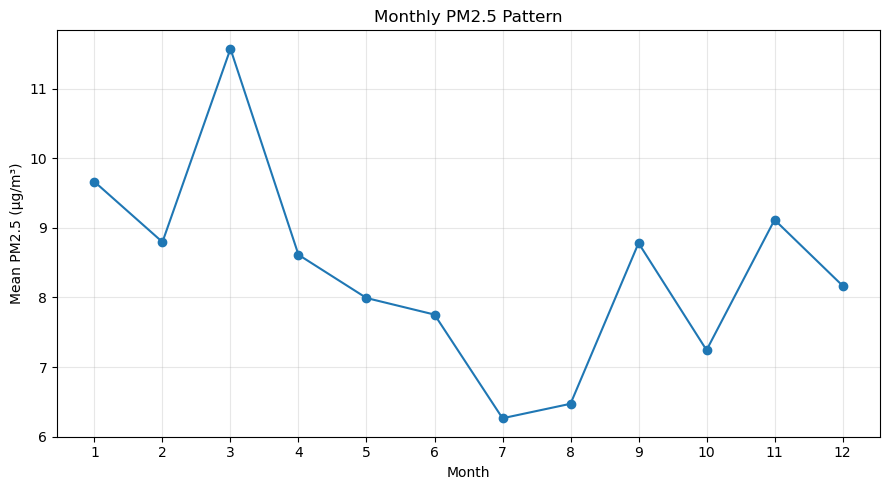

In [35]:
### Plotting monthly PM2.5

plt.figure(figsize=(9, 5))

monthly_pm25.plot(
    kind="line",
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Mean PM2.5 (µg/m³)")
plt.title("Monthly PM2.5 Pattern")

plt.xticks(range(1, 13))
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "pm25_monthly_pattern.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

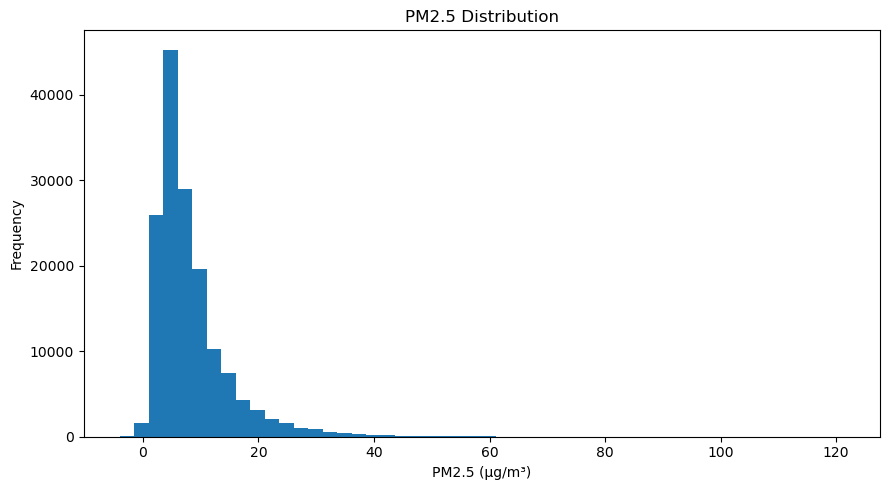

In [36]:
# Plotting PM2.5 distribution

plt.figure(figsize=(9, 5))

df["PM2.5"].dropna().plot(
    kind="hist",
    bins=50
)

plt.xlabel("PM2.5 (µg/m³)")
plt.ylabel("Frequency")
plt.title("PM2.5 Distribution")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "pm25_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [42]:
# Creating day type

df["DayType"] = np.where(
    df["DayOfWeek"] < 5,
    "Weekday",
    "Weekend"
)

# Calculating PM2.5 by day type

daytype_pm25 = (
    df.groupby("DayType")["PM2.5"]
    .mean()
)

daytype_pm25.round(2)

DayType
Weekday    8.32
Weekend    8.44
Name: PM2.5, dtype: float64

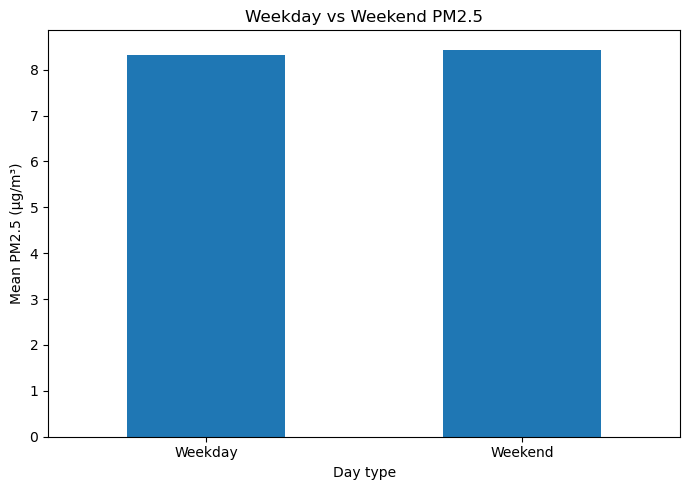

In [44]:
# Plotting weekday vs weekend

plt.figure(figsize=(7, 5))

daytype_pm25.plot(
    kind="bar"
)

plt.xlabel("Day type")
plt.ylabel("Mean PM2.5 (µg/m³)")
plt.title("Weekday vs Weekend PM2.5")

plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "pm25_weekday_weekend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [45]:
# Calculating weather correlations

weather_variables = [
    "Temperature",
    "Dewpoint",
    "Humidity",
    "WindSpeed",
    "WindDirection",
    "Pressure",
    "Visibility"
]

weather_corr = (
    df[weather_variables + ["PM2.5"]]
    .corr()["PM2.5"]
    .drop("PM2.5")
    .sort_values()
)

weather_corr.round(2)

Visibility      -0.48
WindSpeed       -0.29
WindDirection   -0.18
Temperature     -0.16
Dewpoint        -0.13
Humidity         0.10
Pressure         0.21
Name: PM2.5, dtype: float64

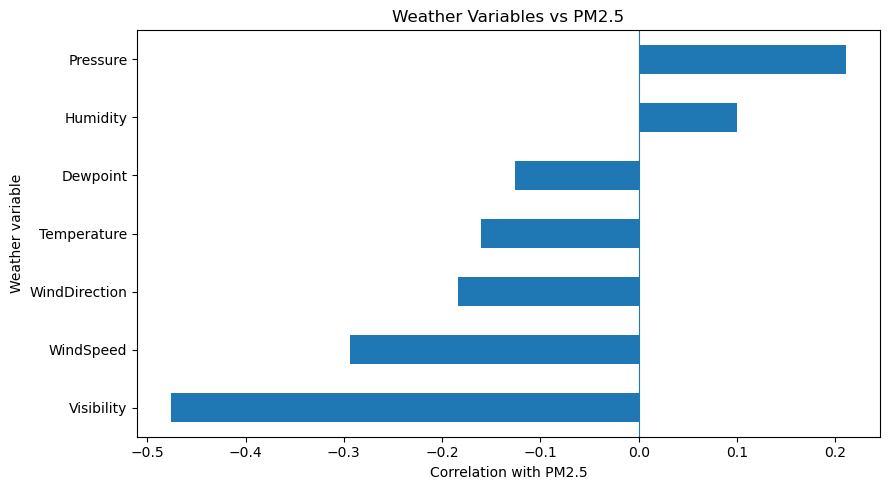

In [46]:
# Plotting weather correlations

plt.figure(figsize=(9, 5))

weather_corr.plot(
    kind="barh"
)

plt.xlabel("Correlation with PM2.5")
plt.ylabel("Weather variable")
plt.title("Weather Variables vs PM2.5")

plt.axvline(0, linewidth=0.8)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "weather_pm25_correlation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [47]:
# Creating EDA summary

eda_summary = pd.DataFrame({
    "Variable": pollutants,
    "Missing_Percentage": [
        df[p].isna().mean() * 100
        for p in pollutants
    ],
    "Mean": [
        df[p].mean()
        for p in pollutants
    ],
    "Median": [
        df[p].median()
        for p in pollutants
    ],
    "Minimum": [
        df[p].min()
        for p in pollutants
    ],
    "Maximum": [
        df[p].max()
        for p in pollutants
    ]
})

eda_summary.round(2)

,Variable,Missing_Percentage,Mean,Median,Minimum,Maximum
0,NO2,22.47,26.25,20.89,0.00,241.36
1,PM10,3.43,14.11,11.60,-3.77,857.18
2,PM2.5,8.13,8.36,6.37,-4.00,121.32
3,O3,20.99,44.26,44.50,-0.80,189.69
